# Menavigasi Ketimpangan Layanan Kesehatan
## Model Optimasi Alokasi Rumah Sakit Baru di Jawa Timur Berbasis Pemrograman Linear

**Tim:** Udah Bukan Maba (ID Tim IMC25EC35)

**Kompetisi:** IPB Mathematics Challenge (IMC) 2026 Kompetisi Esai

**Subtema:** Applied Probability & Risk Management

---

Notebook ini menyajikan seluruh proses analisis data dan pemodelan matematis yang mendasari esai, mulai dari pembersihan data mentah BPS, eksplorasi ketimpangan rasio rumah sakit, hingga model pemrograman linear (linear programming) untuk menentukan alokasi optimal rumah sakit baru di Provinsi Jawa Timur.

### Gambaran Masalah
- **Data**: Jumlah rumah sakit dan jumlah penduduk, level nasional (38 provinsi) dan level Jawa Timur (38 kabupaten/kota), sumber Badan Pusat Statistik (BPS), rentang tahun 2020-2025.
- **Masalah inti**: Rasio rumah sakit per 100.000 penduduk secara nasional (1,04) jauh di bawah standar negara berkembang maupun rekomendasi OECD, dan ketimpangan antarwilayah di Jawa Timur mencapai belasan kali lipat.
- **Tujuan**: Merumuskan strategi alokasi rumah sakit baru yang meminimalkan total defisit terbobot risiko, dengan anggaran pembangunan yang terbatas.

### Pendekatan
1. **Pembersihan & penggabungan data** dari banyak berkas CSV BPS dengan format kolom yang tidak konsisten antar tahun.
2. **Eksplorasi data (EDA)**: identifikasi wilayah dengan rasio terendah/tertinggi, korelasi kepadatan penduduk terhadap rasio RS, tren pertumbuhan 2020→2025.
3. **Perhitungan skor risiko dan defisit** tiap wilayah relatif terhadap standar ideal (1 RS per 100.000 penduduk).
4. **Model pemrograman linear (Integer LP)** dengan solver CBC (`PuLP`) dua skenario: tanpa batas alokasi per wilayah (Skenario A) vs dengan batas maksimum per wilayah (Skenario B), untuk menguji trade-off efisiensi matematis vs pemerataan kebijakan.
5. **Analisis sensitivitas**: uji signifikansi statistik korelasi, kurva trade-off Pareto (variasi batas alokasi), dan sensitivitas terhadap besaran anggaran.

### Struktur Notebook

| Cell | Deskripsi |
|---|---|
| 0 | Instalasi Library dan Setup Awal |
| 1 | Upload Berkas Data ke Colab |
| 2 | Load & Pembersihan Data Rumah Sakit Nasional (2020 & 2025) |
| 3 | Load & Gabungkan Data Rumah Sakit Jawa Timur (2022-2025) |
| 4 | Load Data Kependudukan Nasional |
| 5 | Load Data Kependudukan Jawa Timur |
| 6 | Normalisasi Nama Wilayah & Penggabungan Dataset |
| 7 | Ringkasan Statistik: Rasio RS Tertinggi & Terendah |
| 8 | Visualisasi Kesenjangan Rasio RS (5 Terendah vs 5 Tertinggi) |
| 9 | Analisis Korelasi dan Tren Pertumbuhan 2020→2025 |
| 10 | Menghitung Defisit dan Skor Risiko per Wilayah |
| 11 | Model Optimasi Skenario A (Tanpa Batas Alokasi) |
| 12 | Model Optimasi Skenario B (Pemerataan) & Perbandingan Skenario |
| 13 | Uji Signifikansi Korelasi (Pearson) |
| 14 | Analisis Sensitivitas Batas Alokasi (Kurva Pareto) |
| 15 | Analisis Sensitivitas Anggaran |

## Cell 0
## Instalasi Library dan Setup Awal

### Library yang Digunakan

| Library | Fungsi |
|---|---|
| `pulp` | Solver pemrograman linear (linear programming) dipakai untuk model optimasi alokasi rumah sakit |
| `pandas` | Manipulasi dan penggabungan data tabular dari banyak berkas CSV |
| `numpy` | Komputasi numerik (pembulatan, operasi array) |
| `matplotlib` | Visualisasi data (bar chart, dsb.) |

### Konfigurasi
`pd.set_option('display.width', 120)` melebarkan tampilan output tabel pandas di Colab agar kolom tidak terpotong saat dicetak.

In [1]:
!pip install pulp -q

import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)

## Cell 1
## Upload Berkas Data ke Colab

### Tujuan
Menyediakan mekanisme upload interaktif untuk seluruh berkas CSV mentah (data BPS jumlah rumah sakit dan kependudukan, nasional maupun Jawa Timur) ke lingkungan Google Colab.

### Cara Kerja
- Blok `try/except` mendeteksi apakah notebook berjalan di Google Colab (`google.colab.files`). Jika ya, jendela upload file akan muncul.
- Jika dijalankan di luar Colab (mis. lokal/Jupyter biasa) dan modul tidak tersedia, notebook akan menampilkan pesan pengingat untuk menyiapkan data secara manual di direktori kerja.
- Variabel `UP = "."` menyimpan path direktori tempat seluruh berkas CSV dibaca pada cell-cell berikutnya.

In [2]:
try:
    from google.colab import files
    uploaded = files.upload()
    print("File terupload:", list(uploaded.keys()))
except ImportError:
    print("up datanya ya")

UP = "."

Saving trend_nasional_2020_2025.csv to trend_nasional_2020_2025.csv
Saving trend_jatim_2024_2025.csv to trend_jatim_2024_2025.csv
Saving Number of General Hospital, Specialized Hospital, Public Health Center, Primary Clinic, and Integrated Health Post by Province, 2020.csv to Number of General Hospital, Specialized Hospital, Public Health Center, Primary Clinic, and Integrated Health Post by Province, 2020.csv
Saving Number of General Hospital, Specialized Hospital, Public Health Center with Inpatient Care, and Public Health Center without Inpatient Care by Province, 2025.csv to Number of General Hospital, Specialized Hospital, Public Health Center with Inpatient Care, and Public Health Center without Inpatient Care by Province, 2025.csv
Saving jatim_25.csv to jatim_25.csv
Saving jatim_24.csv to jatim_24.csv
Saving jatim_23.csv to jatim_23.csv
Saving jatim_22.csv to jatim_22.csv
Saving indeks_risiko_jatim_2025.csv to indeks_risiko_jatim_2025.csv
Saving hasil_alokasi_lp_jatim_skenarioB.

## Cell 2
## Load & Pembersihan Data Rumah Sakit Nasional (2020 & 2025)

### Sumber Data
Data jumlah fasilitas kesehatan per provinsi dari Badan Pusat Statistik (BPS), dua vintage tahun:
- **2020**: `clean_nasional_2020.csv` menggunakan batas wilayah lama (pra-pemekaran Provinsi Papua).
- **2025**: `clean_nasional_2025.csv` menggunakan batas wilayah baru (38 provinsi, pasca-pemekaran Papua).

### Fungsi `clean_numeric`
Banyak nilai pada berkas mentah BPS bukan angka murni tanda strip (`-`, `–`) untuk nol/tidak tersedia, pemisah ribuan koma, atau elipsis (`...`) untuk sel kosong. Fungsi ini menyeragamkan representasi tersebut sebelum dikonversi ke tipe numerik dengan `pd.to_numeric(errors="coerce")`.

### Langkah Pembersihan
1. Standardisasi nama kolom (`rs_umum`, `rs_khusus`, `puskesmas_rawat_inap`, dst.).
2. Membuang baris agregat (`"Indonesia"`) dan baris keterangan/catatan kaki yang ikut terbaca sebagai baris data (mengandung `"sup>"` atau teks catatan).
3. Menambahkan kolom `tahun` sebagai penanda vintage data.

Output cell mencetak dimensi kedua dataset perbandingan jumlah provinsi (37 di 2020 vs 38 di 2025) menjadi alasan mengapa analisis tren nasional di Cell 9 perlu menyamakan cakupan wilayah terlebih dahulu.

In [3]:
def clean_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = (df[c].astype(str)
                     .str.replace("–", "0", regex=False)
                     .str.replace("-", "0", regex=False)
                     .str.replace("...", "", regex=False)
                     .str.replace(",", "", regex=False)
                     .str.strip())
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

df_nat_2020 = pd.read_csv(f"{UP}/clean_nasional_2020.csv")
df_nat_2020.columns = [c.strip() for c in df_nat_2020.columns]
df_nat_2020 = df_nat_2020.rename(columns={
    "Provinsi": "wilayah",
    "Number of General Hospital": "rs_umum",
    "Number of Specialized Hospital": "rs_khusus",
    "Number of Public Health Center with Inpatient Care": "puskesmas_rawat_inap",
    "Number of Public Health Center without Inpatient Care": "puskesmas_non_rawat_inap",
    "Number of Primary Clinic": "klinik_pratama",
    "Number of Integrated Health Post": "posyandu",
})
df_nat_2020 = df_nat_2020[~df_nat_2020["wilayah"].isin(["Indonesia", "Keterangan"])]
df_nat_2020 = df_nat_2020[df_nat_2020["wilayah"].notna()]
df_nat_2020 = df_nat_2020[~df_nat_2020["wilayah"].astype(str).str.contains("sup>|Puskesmas yang", na=False)]
df_nat_2020["tahun"] = 2020
df_nat_2020 = clean_numeric(df_nat_2020, ["rs_umum","rs_khusus","puskesmas_rawat_inap","puskesmas_non_rawat_inap","klinik_pratama","posyandu"])

df_nat_2025 = pd.read_csv(f"{UP}/clean_nasional_2025.csv")
df_nat_2025.columns = [c.strip() for c in df_nat_2025.columns]
df_nat_2025 = df_nat_2025.rename(columns={
    "Provinsi": "wilayah",
    "Number of General Hospital": "rs_umum",
    "Number of Specialized Hospital": "rs_khusus",
    "Number of Public Health Center with Inpatient Care": "puskesmas_rawat_inap",
    "Number of Public Health Center without Inpatient Care": "puskesmas_non_rawat_inap",
})
df_nat_2025 = df_nat_2025[~df_nat_2025["wilayah"].isin(["Indonesia", "Keterangan"])]
df_nat_2025 = df_nat_2025[df_nat_2025["wilayah"].notna()]
df_nat_2025 = df_nat_2025[~df_nat_2025["wilayah"].astype(str).str.contains("Data Puskesmas", na=False)]
df_nat_2025["tahun"] = 2025
df_nat_2025 = clean_numeric(df_nat_2025, ["rs_umum","rs_khusus","puskesmas_rawat_inap","puskesmas_non_rawat_inap"])

print("Nasional 2020:", df_nat_2020.shape, "provinsi (boundary lama, pra-pemekaran Papua)")
print("Nasional 2025:", df_nat_2025.shape, "provinsi (boundary baru, 38 provinsi)")
df_nat_2025.head()

Nasional 2020: (34, 8) provinsi (boundary lama, pra-pemekaran Papua)
Nasional 2025: (38, 6) provinsi (boundary baru, 38 provinsi)


,wilayah,rs_umum,rs_khusus,puskesmas_rawat_inap,puskesmas_non_rawat_inap,tahun
0,Aceh,77.0,9,174.0,192.0,2025
1,Sumatera Utara,185.0,23,178.0,441.0,2025
2,Sumatera Barat,53.0,30,108.0,172.0,2025
3,Riau,67.0,14,120.0,122.0,2025
4,Jambi,42.0,3,98.0,110.0,2025


## Cell 3
## Load & Gabungkan Data Rumah Sakit Jawa Timur (2022-2025)

### Sumber Data
Empat berkas terpisah per tahun (`jatim_22.csv` s.d. `jatim_25.csv`), masing-masing berisi jumlah fasilitas kesehatan per kabupaten/kota di Jawa Timur.

### Langkah Pemrosesan
- Iterasi atas empat tahun (2022-2025), setiap berkas di-load, kolom diseragamkan namanya, lalu dibersihkan dengan `clean_numeric` (fungsi yang sama dari Cell 2).
- Baris agregat provinsi (`"Jawa Timur"`) dan baris noise (catatan kaki, RS Bersalin yang sudah tidak beroperasi, RSIA, klinik pratama yang ikut terbaca sebagai baris wilayah) difilter keluar.
- Seluruh tahun digabung menjadi satu dataframe `df_jatim` dengan `pd.concat`.

### Pemeriksaan Konsistensi
Output cell menampilkan jumlah kabupaten/kota unik per tahun (`groupby("tahun")`) untuk memastikan tidak ada wilayah yang hilang akibat kesalahan filter pada salah satu vintage data.

In [4]:
jatim_frames = []
for th in [2022, 2023, 2024, 2025]:
    d = pd.read_csv(f"{UP}/jatim_{str(th)[-2:]}.csv")
    d.columns = [c.strip() for c in d.columns]
    d = d.rename(columns={
        "Kabupaten/Kota": "wilayah",
        "Number of General Hospital": "rs_umum",
        "Number of Specialized Hospital": "rs_khusus",
        "Number of Public Health Center with Inpatient Care": "puskesmas_rawat_inap",
        "Number of Public Health Center without Inpatient Care": "puskesmas_non_rawat_inap",
        "Number of Primary Clinic": "klinik_pratama",
        "Number of Integrated Health Post": "posyandu",
    })
    d = d[~d["wilayah"].isin(["Jawa Timur", "Keterangan"])]
    d = d[d["wilayah"].notna()]
    d = d[~d["wilayah"].astype(str).str.contains(
        "sup>|RS Bersalin|masuk dalam|Klinik Pratama|no longer exist|RSIA|Mother and Child",
        na=False)]
    d = clean_numeric(d, ["rs_umum","rs_khusus","puskesmas_rawat_inap","puskesmas_non_rawat_inap","klinik_pratama","posyandu"])
    d["tahun"] = th
    jatim_frames.append(d)

df_jatim = pd.concat(jatim_frames, ignore_index=True)
print("Jatim gabungan:", df_jatim.shape)
print("Jumlah kab/kota per tahun:")
print(df_jatim.groupby("tahun")["wilayah"].nunique())
df_jatim.head()

Jatim gabungan: (152, 8)
Jumlah kab/kota per tahun:
tahun
2022    38
2023    38
2024    38
2025    38
Name: wilayah, dtype: int64


,wilayah,rs_umum,rs_khusus,puskesmas_rawat_inap,puskesmas_non_rawat_inap,klinik_pratama,posyandu,tahun
0,Pacitan,3.0,0.0,15,9,18.0,861.0,2022
1,Ponorogo,7.0,0.0,19,13,53.0,1137.0,2022
2,Trenggalek,3.0,1.0,19,3,19.0,865.0,2022
3,Tulungagung,10.0,3.0,17,15,52.0,1239.0,2022
4,Blitar,8.0,0.0,16,9,26.0,1385.0,2022


## Cell 4
## Load Data Kependudukan Nasional

### Sumber Data
Data jumlah dan kepadatan penduduk per provinsi dari BPS (`clean_penduduk_nasional_2020.csv` dan `..._2025.csv`).

### Fungsi `load_national_pop`
- Merename kolom BPS yang panjang (mis. `"Kepadatan Penduduk per km persegi (Km2)"`) menjadi nama pendek dan konsisten (`kepadatan_per_km2`).
- Membuang baris agregat nasional dan baris catatan kaki/metodologi yang ikut terbaca sebagai data.
- Mengonversi kolom numerik dan menambahkan penanda `tahun`.
- Mengembalikan hanya kolom yang relevan untuk analisis: `wilayah`, `penduduk`, `kepadatan_per_km2`, `laju_pertumbuhan`, `tahun`.

Data kependudukan inilah yang nantinya digabung dengan data jumlah rumah sakit (Cell 6) untuk menghitung rasio RS per 100.000 penduduk.

In [5]:
def load_national_pop(path, tahun):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={
        "Provinsi": "wilayah",
        "Laju Pertumbuhan Penduduk per Tahun": "laju_pertumbuhan",
        "Persentase Penduduk": "persen_penduduk",
        "Kepadatan Penduduk per km persegi (Km2)": "kepadatan_per_km2",
        "Rasio Jenis Kelamin Penduduk": "rasio_jenis_kelamin",
    }, errors='ignore')
    df = df[df["wilayah"].notna()]
    df = df[~df["wilayah"].isin(["Indonesia", "Keterangan"])]
    df = df[~df["wilayah"].astype(str).str.contains("sup>|Hasil Sensus|Hasil Proyeksi|Dalam Negeri|Laju pertumbuhan", na=False)]
    for c in ["penduduk","laju_pertumbuhan","persen_penduduk","kepadatan_per_km2","rasio_jenis_kelamin"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df["tahun"] = tahun
    return df[["wilayah","penduduk","kepadatan_per_km2","laju_pertumbuhan","tahun"]]

pop_nat_2020 = load_national_pop(f"{UP}/clean_penduduk_nasional_2020.csv", 2020)
pop_nat_2025 = load_national_pop(f"{UP}/clean_penduduk_nasional_2025.csv", 2025)

print("Penduduk nasional 2020:", pop_nat_2020.shape)
print("Penduduk nasional 2025:", pop_nat_2025.shape)
pop_nat_2025.head()

Penduduk nasional 2020: (34, 5)
Penduduk nasional 2025: (38, 5)


,wilayah,penduduk,kepadatan_per_km2,laju_pertumbuhan,tahun
0,Aceh,5626000.0,99.0,1.37,2025
1,Sumatera Utara,15785800.0,218.0,1.37,2025
2,Sumatera Barat,5914300.0,140.0,1.41,2025
3,Riau,6811200.0,76.0,1.34,2025
4,Jambi,3768500.0,77.0,1.28,2025


## Cell 5
## Load Data Kependudukan Jawa Timur

### Sumber Data
Berkas kependudukan per kabupaten/kota Jawa Timur (`2024_3.csv`, `2025_3.csv`) dengan format BPS yang sedikit berbeda dari data nasional format tabel memiliki 4 baris header/judul di bagian atas yang perlu dilewati (`skiprows=4`), dengan kolom Laki-laki (L), Perempuan (P), dan Total.

### Fungsi `load_jatim_pop`
- Membaca CSV tanpa header otomatis, memberi nama kolom secara manual (`wilayah, L, P, total`).
- Membuang baris agregat provinsi (`"Jawa Timur"`) dan baris dengan nilai total kosong (`dropna`).
- Mengembalikan kolom `wilayah`, `penduduk` (hasil rename dari `total`), dan `tahun`.

Dua tahun (2024, 2025) digabung menjadi satu dataframe `pop_jatim` yang menjadi basis populasi terbaru untuk perhitungan rasio dan model optimasi.

In [6]:
def load_jatim_pop(path, tahun):
    df = pd.read_csv(path, skiprows=4, header=None, names=["wilayah","L","P","total"])
    df = df[df["wilayah"].notna()]
    df = df[df["wilayah"] != "Jawa Timur"]
    for c in ["L","P","total"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["total"])
    df["tahun"] = tahun
    return df[["wilayah","total","tahun"]].rename(columns={"total":"penduduk"})

pop_jatim_2024 = load_jatim_pop(f"{UP}/2024_3.csv", 2024)
pop_jatim_2025 = load_jatim_pop(f"{UP}/2025_3.csv", 2025)
pop_jatim = pd.concat([pop_jatim_2024, pop_jatim_2025], ignore_index=True)

print("Penduduk Jatim gabungan:", pop_jatim.shape)
pop_jatim.head()

Penduduk Jatim gabungan: (76, 3)


,wilayah,penduduk,tahun
0,Kabupaten Pacitan,588569,2024
1,Kabupaten Ponorogo,962941,2024
2,Kabupaten Trenggalek,744516,2024
3,Kabupaten Tulungagung,1113847,2024
4,Kabupaten Blitar,1263645,2024


## Cell 6
## Normalisasi Nama Wilayah & Penggabungan Dataset

### Masalah: Inkonsistensi Penamaan Wilayah
Nama wilayah yang sama sering ditulis berbeda antar berkas BPS (mis. `"Prov. Jawa Barat"` vs `"Jawa Barat"`, atau kabupaten yang kadang ditulis tanpa prefiks `"Kabupaten"`). Tanpa normalisasi, proses `merge` antar dataframe akan kehilangan banyak baris karena kunci penggabungan tidak cocok persis.

### Fungsi Normalisasi
- `norm_wilayah`: menghapus prefiks `"Prov. "`, menyeragamkan `"DI "` → `"Di "`, dan menerapkan title case.
- `norm_wilayah_jatim_rs`: tambahan khusus data RS Jawa Timur menambahkan prefiks `"Kabupaten "` pada wilayah yang belum berprefiks `"Kota "`, karena berkas RS Jatim tidak selalu konsisten mencantumkan jenis wilayah (beda dengan berkas kependudukan).

### Penggabungan (Merge)
- Data rumah sakit nasional (2020, 2025) digabung dengan data kependudukan nasional pada kunci `wilayah_key`, menghasilkan `nat_2020` dan `nat_2025`.
- Data rumah sakit Jawa Timur (difilter hanya tahun 2024-2025) digabung dengan data kependudukan Jawa Timur pada kunci `wilayah_key` + `tahun`, menghasilkan `jatim_merged`.
- Metrik utama **rasio rumah sakit per 100.000 penduduk** dihitung: `rs_per_100rb = total_rs / (penduduk / 100000)`, dengan `total_rs = rs_umum + rs_khusus`.

Output cell mencetak jumlah baris yang berhasil dicocokkan (`matched`) dibanding jumlah baris asli, sebagai pemeriksaan kualitas penggabungan data.

In [7]:
def norm_wilayah(s):
    return (s.astype(str).str.strip()
            .str.replace("Prov. ", "", regex=False)
            .str.replace("DI ", "Di ", regex=False)
            .str.title())

def norm_wilayah_jatim_rs(s):
    s = norm_wilayah(s)
    return s.where(s.str.startswith("Kota "), "Kabupaten " + s)

for df in [df_nat_2020, df_nat_2025, pop_nat_2020, pop_nat_2025, pop_jatim]:
    df["wilayah_key"] = norm_wilayah(df["wilayah"])
df_jatim["wilayah_key"] = norm_wilayah_jatim_rs(df_jatim["wilayah"])

df_nat_2020["total_rs"] = df_nat_2020["rs_umum"] + df_nat_2020["rs_khusus"]
df_nat_2025["total_rs"] = df_nat_2025["rs_umum"] + df_nat_2025["rs_khusus"]

nat_2020 = df_nat_2020.merge(pop_nat_2020, on="wilayah_key", suffixes=("", "_pop"))
nat_2025 = df_nat_2025.merge(pop_nat_2025, on="wilayah_key", suffixes=("", "_pop"))
for d in [nat_2020, nat_2025]:
    d["rs_per_100rb"] = d["total_rs"] / (d["penduduk"] / 100000)

print("Matched nasional 2020:", len(nat_2020), "/", len(df_nat_2020))
print("Matched nasional 2025:", len(nat_2025), "/", len(df_nat_2025))

rs_jatim_2425 = df_jatim[df_jatim.tahun.isin([2024,2025])].copy()
rs_jatim_2425["total_rs"] = rs_jatim_2425["rs_umum"] + rs_jatim_2425["rs_khusus"]
jatim_merged = rs_jatim_2425.merge(pop_jatim, on=["wilayah_key","tahun"], suffixes=("", "_pop"))
jatim_merged["rs_per_100rb"] = jatim_merged["total_rs"] / (jatim_merged["penduduk"] / 100000)

print("Matched Jatim:", len(jatim_merged), "/", len(rs_jatim_2425))
jatim_merged.head()

Matched nasional 2020: 34 / 34
Matched nasional 2025: 38 / 38
Matched Jatim: 76 / 76


,wilayah,rs_umum,rs_khusus,puskesmas_rawat_inap,puskesmas_non_rawat_inap,klinik_pratama,posyandu,tahun,wilayah_key,total_rs,wilayah_pop,penduduk,rs_per_100rb
0,Pacitan,3.0,0.0,15,9,17.0,843.0,2024,Kabupaten Pacitan,3.0,Kabupaten Pacitan,588569,0.509711
1,Ponorogo,8.0,0.0,19,12,49.0,1134.0,2024,Kabupaten Ponorogo,8.0,Kabupaten Ponorogo,962941,0.830788
2,Trenggalek,3.0,0.0,20,2,25.0,858.0,2024,Kabupaten Trenggalek,3.0,Kabupaten Trenggalek,744516,0.402946
3,Tulungagung,10.0,0.0,17,15,52.0,1242.0,2024,Kabupaten Tulungagung,10.0,Kabupaten Tulungagung,1113847,0.897789
4,Blitar,8.0,0.0,18,6,26.0,1472.0,2024,Kabupaten Blitar,8.0,Kabupaten Blitar,1263645,0.633089


## Cell 7
## Ringkasan Statistik: Rasio RS Tertinggi & Terendah

### Tujuan
Memberi gambaran awal skala ketimpangan sebelum masuk ke tahap pemodelan, baik di level nasional maupun level kabupaten/kota Jawa Timur.

### Isi Output
- 5 provinsi dengan rasio RS/100rb **terendah** dan **tertinggi** (data 2025).
- Rata-rata nasional `rs_per_100rb`.
- 5 kabupaten/kota Jawa Timur dengan rasio **terendah** dan **tertinggi** (`j25`, subset `jatim_merged` tahun 2025).

Angka-angka inilah yang menjadi rujukan temuan "selisih 16 kali lipat antarkabupaten/kota" pada esai (mis. Kabupaten Trenggalek vs Kota Mojokerto).

In [8]:
print("5 Provinsi rasio RS/100rb TERENDAH (2025)")
print(nat_2025.sort_values('rs_per_100rb')[['wilayah','total_rs','penduduk','rs_per_100rb']].head(5).to_string(index=False))

print("\n5 Provinsi rasio RS/100rb TERTINGGI (2025)")
print(nat_2025.sort_values('rs_per_100rb', ascending=False)[['wilayah','total_rs','penduduk','rs_per_100rb']].head(5).to_string(index=False))

print("\nRata-rata nasional rs_per_100rb:", round(nat_2025['rs_per_100rb'].mean(), 3))

j25 = jatim_merged[jatim_merged.tahun == 2025].copy()
print("\n5 Kab/Kota Jatim rasio TERENDAH (2025)")
print(j25.sort_values('rs_per_100rb')[['wilayah','total_rs','penduduk','rs_per_100rb']].head(5).to_string(index=False))
print("\n5 Kab/Kota Jatim rasio TERTINGGI (2025)")
print(j25.sort_values('rs_per_100rb', ascending=False)[['wilayah','total_rs','penduduk','rs_per_100rb']].head(5).to_string(index=False))

5 Provinsi rasio RS/100rb TERENDAH (2025)
            wilayah  total_rs   penduduk  rs_per_100rb
   Papua Pegunungan       8.0  1484900.0      0.538757
Nusa Tenggara Barat      46.0  5731100.0      0.802638
         Jawa Barat     436.0 50759000.0      0.858961
            Lampung      83.0  9522900.0      0.871583
       Papua Tengah      14.0  1492300.0      0.938149

5 Provinsi rasio RS/100rb TERTINGGI (2025)
         wilayah  total_rs  penduduk  rs_per_100rb
     Papua Barat      14.0  587600.0      2.382573
Kalimantan Utara      17.0  749400.0      2.268481
  Sulawesi Utara      60.0 2721400.0      2.204748
   DI Yogyakarta      80.0 3781500.0      2.115563
Papua Barat Daya      12.0  636400.0      1.885607

Rata-rata nasional rs_per_100rb: 1.411

5 Kab/Kota Jatim rasio TERENDAH (2025)
   wilayah  total_rs  penduduk  rs_per_100rb
Trenggalek       2.0    747614      0.267518
   Sampang       3.0   1027538      0.291960
     Ngawi       3.0    887172      0.338153
   Sumenep       4

## Cell 8
## Visualisasi Kesenjangan Rasio RS (5 Terendah vs 5 Tertinggi)

### Tujuan
Menampilkan kesenjangan rasio RS antarwilayah Jawa Timur secara visual dalam satu grafik, alih-alih hanya berupa angka pada tabel.

### Cara Membaca Grafik
- Horizontal bar chart menggabungkan 5 wilayah dengan rasio terendah dan 5 wilayah dengan rasio tertinggi (`plot_df`), diurutkan naik agar posisi wilayah dengan rasio rendah dan tinggi mudah dibandingkan.
- Garis vertikal putus-putus merah pada `x = 1.0` menandai **standar acuan** (1 RS per 100.000 penduduk) yang dipakai sebagai ambang batas ideal sepanjang analisis.
- Wilayah dengan batang di kiri garis merah berarti berada di bawah standar (kekurangan RS relatif terhadap penduduknya).

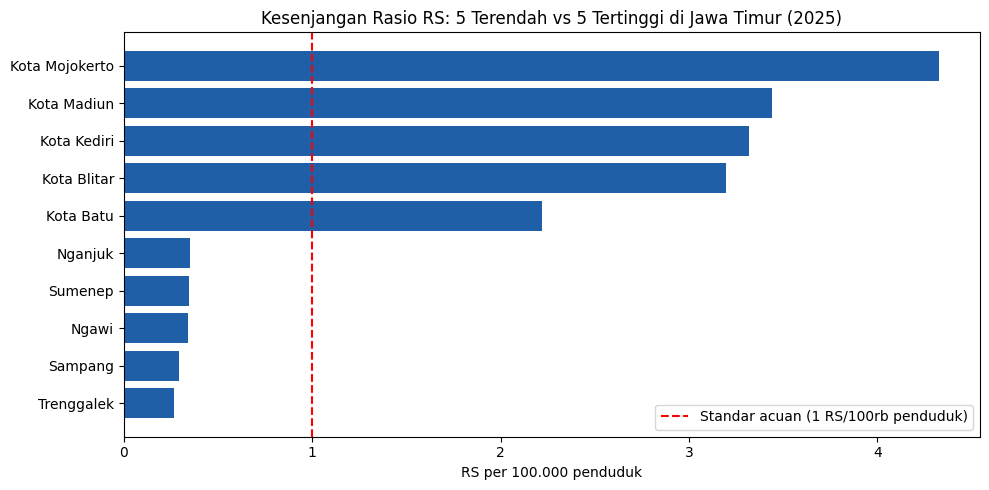

In [9]:
plot_df = pd.concat([
    j25.sort_values('rs_per_100rb').head(5),
    j25.sort_values('rs_per_100rb', ascending=False).head(5)
]).sort_values('rs_per_100rb')

plt.figure(figsize=(10,5))
plt.barh(plot_df['wilayah'], plot_df['rs_per_100rb'], color='#1f5fa8')
plt.axvline(1.0, color='red', linestyle='--', label='Standar acuan (1 RS/100rb penduduk)')
plt.xlabel('RS per 100.000 penduduk')
plt.title('Kesenjangan Rasio RS: 5 Terendah vs 5 Tertinggi di Jawa Timur (2025)')
plt.legend()
plt.tight_layout()
plt.show()

## Cell 9
## Analisis Korelasi dan Tren Pertumbuhan 2020→2025

### Bagian 1: Korelasi Cross-Sectional (2025)
Matriks korelasi Pearson antara `rs_per_100rb`, `kepadatan_per_km2`, dan `penduduk` pada data nasional 2025. Korelasi negatif antara rasio RS dan jumlah/kepadatan penduduk mengindikasikan provinsi yang lebih besar/padat justru relatif kurang terlayani inilah yang kemudian diuji signifikansinya secara formal pada Cell 13.

### Bagian 2: Analisis Tren 2020 → 2025
Karena Provinsi Papua mengalami pemekaran (1 provinsi menjadi beberapa provinsi baru) antara 2020 dan 2025, seluruh provinsi terkait Papua **dikecualikan** (`papua_lama`) dari perbandingan tren agar tidak membandingkan wilayah dengan definisi batas yang berbeda.

Untuk wilayah yang tersisa (`common`, irisan nama wilayah di kedua tahun):
- `growth_rs_pct`: persentase pertumbuhan jumlah RS 2020→2025.
- `growth_pop_pct`: persentase pertumbuhan jumlah penduduk pada periode yang sama.
- `gap = growth_pop_pct - growth_rs_pct`: selisih positif berarti penduduk tumbuh lebih cepat daripada penambahan RS, sehingga defisit berpotensi **memburuk** di masa depan jika tidak diantisipasi.

Output menampilkan 5 provinsi dengan `gap` terbesar wilayah yang paling berisiko mengalami perburukan rasio layanan kesehatan pada tren saat ini.

In [10]:
corr = nat_2025[["rs_per_100rb","kepadatan_per_km2","penduduk"]].corr()
print("Korelasi (nasional 2025)")
print(corr.round(3))

papua_lama = ["Papua", "Papua Barat", "Papua Barat Daya", "Papua Selatan", "Papua Tengah", "Papua Pegunungan"]
non_papua_2025 = nat_2025[~nat_2025.wilayah.isin(papua_lama)]
rest2020 = nat_2020[~nat_2020.wilayah.isin(["Papua","Papua Barat"])]

common = set(rest2020.wilayah) & set(non_papua_2025.wilayah)
trend = rest2020[rest2020.wilayah.isin(common)][["wilayah","total_rs","penduduk"]].merge(
    non_papua_2025[non_papua_2025.wilayah.isin(common)][["wilayah","total_rs","penduduk"]],
    on="wilayah", suffixes=("_2020","_2025"))
trend["growth_rs_pct"] = (trend.total_rs_2025/trend.total_rs_2020 - 1)*100
trend["growth_pop_pct"] = (trend.penduduk_2025/trend.penduduk_2020 - 1)*100
trend["gap"] = trend["growth_pop_pct"] - trend["growth_rs_pct"]

print("\nProvinsi dengan RISIKO MEMBURUK (penduduk tumbuh lebih cepat dari RS)")
print(trend.sort_values("gap", ascending=False)[["wilayah","growth_rs_pct","growth_pop_pct","gap"]].head(5).round(2).to_string(index=False))

Korelasi (nasional 2025)
                   rs_per_100rb  kepadatan_per_km2  penduduk
rs_per_100rb              1.000              0.129    -0.391
kepadatan_per_km2         0.129              1.000     0.154
penduduk                 -0.391              0.154     1.000

Provinsi dengan RISIKO MEMBURUK (penduduk tumbuh lebih cepat dari RS)
        wilayah  growth_rs_pct  growth_pop_pct   gap
         Maluku          -6.45            6.58 13.03
 Sumatera Utara          -5.45            6.67 12.12
  DI Yogyakarta          -3.61            3.07  6.69
Sulawesi Tengah           2.50            5.71  3.21
        Lampung           3.75            5.72  1.97


## Cell 10
## Menghitung Defisit dan Skor Risiko per Wilayah

### Standar Acuan
`STANDAR = 1.0` 1 rumah sakit per 100.000 penduduk, dipakai sebagai ambang batas ketersediaan layanan rujukan tingkat kabupaten/kota.

### Perhitungan
Untuk setiap kabupaten/kota Jawa Timur (`j25`):
- **`rs_ideal`** = jumlah RS yang seharusnya ada mengikuti standar: `ceil(penduduk / 100.000 × STANDAR)`.
- **`defisit_rs`** = `rs_ideal - total_rs`, di-clip minimum 0 (wilayah dengan RS melebihi standar tidak dianggap punya "defisit negatif").
- **`skor_risiko`** = `(STANDAR - rs_per_100rb)`, di-clip minimum 0 semakin jauh rasio aktual di bawah standar, semakin tinggi skor risikonya.
- **`skor_risiko_norm`** = skor risiko dinormalisasi ke rentang 0-1 (dibagi nilai maksimumnya), agar bisa dipakai sebagai bobot yang sepadan pada fungsi tujuan model optimasi di Cell 11-12.

### Output
Tabel 10 wilayah dengan defisit RS absolut terbesar, dan total defisit RS se-Jawa Timur (basis perhitungan untuk analisis sensitivitas anggaran di Cell 15: total defisit **143 unit**).

In [11]:
STANDAR = 1.0

j25 = j25.copy()
j25["rs_ideal"] = np.ceil(j25["penduduk"] / 100000 * STANDAR)
j25["defisit_rs"] = (j25["rs_ideal"] - j25["total_rs"]).clip(lower=0)
j25["skor_risiko"] = (STANDAR - j25["rs_per_100rb"]).clip(lower=0)
j25["skor_risiko_norm"] = j25["skor_risiko"] / j25["skor_risiko"].max()
j25 = j25.sort_values("defisit_rs", ascending=False)

print("TOP 10 wilayah dengan DEFISIT RS terbesar")
print(j25[["wilayah","penduduk","total_rs","rs_per_100rb","rs_ideal","defisit_rs"]].head(10).to_string(index=False))
print(f"\nTotal defisit RS se-Jatim: {int(j25['defisit_rs'].sum())} unit")

TOP 10 wilayah dengan DEFISIT RS terbesar
    wilayah  penduduk  total_rs  rs_per_100rb  rs_ideal  defisit_rs
     Jember   2620135      13.0      0.496158      27.0        14.0
     Kediri   1702262       9.0      0.528708      18.0         9.0
  Bangkalan   1112956       4.0      0.359403      12.0         8.0
    Nganjuk   1138604       4.0      0.351307      12.0         8.0
   Pasuruan   1669400       9.0      0.539116      17.0         8.0
    Sampang   1027538       3.0      0.291960      11.0         8.0
    Sumenep   1159397       4.0      0.345007      12.0         8.0
      Tuban   1231374       6.0      0.487261      13.0         7.0
Probolinggo   1193272       5.0      0.419016      12.0         7.0
      Ngawi    887172       3.0      0.338153       9.0         6.0

Total defisit RS se-Jatim: 143 unit


## Cell 11
## Model Optimasi Skenario A (Tanpa Batas Alokasi)

### Formulasi Model Pemrograman Linear (Integer LP)

**Variabel keputusan**: `x_i` jumlah unit rumah sakit baru yang dibangun di wilayah *i*, dengan batas `0 ≤ x_i ≤ defisit_i` (tidak mungkin membangun lebih dari yang dibutuhkan wilayah tersebut).

**Fungsi tujuan** (diminimumkan):

$$\text{Minimumkan } Z = \sum_i (\text{defisit}_i - x_i) \times \text{risiko}_i$$

yaitu total defisit yang *tersisa* setelah pembangunan, dibobot oleh skor risiko tiap wilayah wilayah berisiko tinggi yang defisitnya belum terpenuhi memberi kontribusi lebih besar pada nilai fungsi tujuan.

**Kendala anggaran**: `Σ x_i ≤ BUDGET_UNIT` (40 unit, asumsi kapasitas pembangunan RS baru se-Jawa Timur dalam satu periode perencanaan).

### Solver
Diselesaikan dengan metode simpleks melalui solver **CBC** (Coin-or Branch and Cut) pada pustaka `PuLP`.

### Interpretasi Hasil
Skenario A (tanpa batasan alokasi per wilayah) menghasilkan solusi optimal secara matematis murni umumnya seluruh anggaran akan terkonsentrasi pada segelintir wilayah dengan skor risiko per kapita tertinggi, karena itulah cara paling efisien menurunkan nilai fungsi tujuan inilah yang menjadi titik tolak diskusi trade-off pada Cell 12.

In [12]:
BUDGET_UNIT = 40

wilayah_list = j25["wilayah"].tolist()
defisit = dict(zip(j25.wilayah, j25.defisit_rs))
risiko = dict(zip(j25.wilayah, j25.skor_risiko_norm))
penduduk = dict(zip(j25.wilayah, j25.penduduk))

prob = pulp.LpProblem("Alokasi_RS_Baru_Jatim", pulp.LpMinimize)
x = {w: pulp.LpVariable(f"x_{i}", lowBound=0, upBound=defisit[w], cat="Integer")
     for i, w in enumerate(wilayah_list)}
prob += pulp.lpSum([(defisit[w] - x[w]) * risiko[w] for w in wilayah_list])
prob += pulp.lpSum([x[w] for w in wilayah_list]) <= BUDGET_UNIT
prob.solve(pulp.PULP_CBC_CMD(msg=0))

hasil = pd.DataFrame({
    "wilayah": wilayah_list,
    "defisit_awal": [defisit[w] for w in wilayah_list],
    "rs_baru_dialokasikan": [int(x[w].value()) for w in wilayah_list],
})
hasil["defisit_tersisa"] = hasil["defisit_awal"] - hasil["rs_baru_dialokasikan"]
hasil = hasil.sort_values("rs_baru_dialokasikan", ascending=False)

print("Status solver:", pulp.LpStatus[prob.status])
print(f"Total anggaran terpakai: {hasil['rs_baru_dialokasikan'].sum()} dari {BUDGET_UNIT} unit")
print(f"Nilai objektif: {pulp.value(prob.objective):.3f}")
print(f"Jumlah wilayah tersentuh: {(hasil.rs_baru_dialokasikan > 0).sum()}")
print()
print(hasil.head(15).to_string(index=False))

Status solver: Optimal
Total anggaran terpakai: 40 dari 40 unit
Nilai objektif: 60.703
Jumlah wilayah tersentuh: 6

    wilayah  defisit_awal  rs_baru_dialokasikan  defisit_tersisa
    Sampang           8.0                     8              0.0
    Nganjuk           8.0                     8              0.0
    Sumenep           8.0                     8              0.0
      Ngawi           6.0                     6              0.0
 Trenggalek           6.0                     6              0.0
  Bangkalan           8.0                     4              4.0
   Pasuruan           8.0                     0              8.0
     Kediri           9.0                     0              9.0
     Jember          14.0                     0             14.0
      Tuban           7.0                     0              7.0
Probolinggo           7.0                     0              7.0
 Banyuwangi           5.0                     0              5.0
  Bondowoso           5.0              

## Cell 12
## Model Optimasi Skenario B (Pemerataan) & Perbandingan Skenario

### Perubahan dari Skenario A
Model identik dengan Cell 11, dengan **satu kendala tambahan**: `CAP_PER_WILAYAH = 4` setiap wilayah maksimum menerima 4 unit rumah sakit baru (`upBound=min(defisit_i, CAP_PER_WILAYAH)`). Kendala ini memaksa anggaran tersebar ke lebih banyak wilayah, alih-alih menumpuk di segelintir wilayah saja.

### Perbandingan Skenario
| | Skenario A (tanpa batas) | Skenario B (cap = 4) |
|---|---|---|
| Jumlah wilayah tersentuh | lebih sedikit (~6 wilayah) | lebih banyak (~10 wilayah) |
| Nilai fungsi tujuan | optimal murni (terendah) | sedikit lebih tinggi (~3% lebih besar) |

Trade-off ini precisely mengapa esai merekomendasikan **Skenario B**: kehilangan efisiensi matematis yang kecil ditukar dengan pemerataan yang jauh lebih besar, menghindari risiko sosial-politik mengabaikan wilayah berpenduduk besar (mis. Kabupaten Jember) sepenuhnya.

### Visualisasi
Dua bar chart berdampingan membandingkan (1) jumlah wilayah tersentuh dan (2) nilai fungsi tujuan antara kedua skenario.

PERBANDINGAN SKENARIO
Skenario A (tanpa batas): 6 wilayah tersentuh | nilai objektif 60.70
Skenario B (cap 4/wilayah): 10 wilayah tersentuh | nilai objektif 62.53


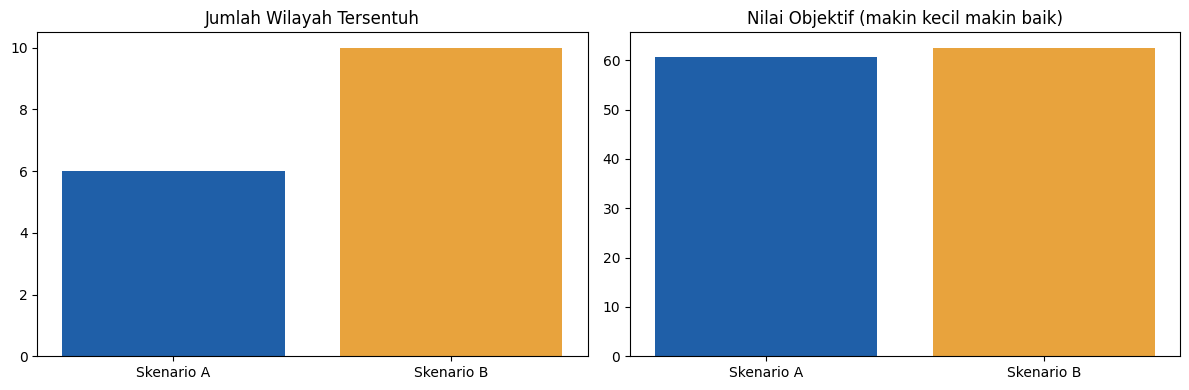

In [13]:
CAP_PER_WILAYAH = 4

prob_b = pulp.LpProblem("Alokasi_RS_Baru_Jatim_Pemerataan", pulp.LpMinimize)
xb = {w: pulp.LpVariable(f"xb_{i}", lowBound=0, upBound=min(defisit[w], CAP_PER_WILAYAH), cat="Integer")
      for i, w in enumerate(wilayah_list)}
prob_b += pulp.lpSum([(defisit[w] - xb[w]) * risiko[w] for w in wilayah_list])
prob_b += pulp.lpSum([xb[w] for w in wilayah_list]) <= BUDGET_UNIT
prob_b.solve(pulp.PULP_CBC_CMD(msg=0))

hasil_b = pd.DataFrame({
    "wilayah": wilayah_list,
    "defisit_awal": [defisit[w] for w in wilayah_list],
    "rs_baru_dialokasikan": [int(xb[w].value()) for w in wilayah_list],
})
hasil_b["defisit_tersisa"] = hasil_b["defisit_awal"] - hasil_b["rs_baru_dialokasikan"]

n_a = (hasil.rs_baru_dialokasikan > 0).sum()
n_b = (hasil_b.rs_baru_dialokasikan > 0).sum()

print("PERBANDINGAN SKENARIO")
print(f"Skenario A (tanpa batas): {n_a} wilayah tersentuh | nilai objektif {pulp.value(prob.objective):.2f}")
print(f"Skenario B (cap {CAP_PER_WILAYAH}/wilayah): {n_b} wilayah tersentuh | nilai objektif {pulp.value(prob_b.objective):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(["Skenario A","Skenario B"], [n_a, n_b], color=['#1f5fa8','#e8a33d'])
ax[0].set_title("Jumlah Wilayah Tersentuh")
ax[1].bar(["Skenario A","Skenario B"], [pulp.value(prob.objective), pulp.value(prob_b.objective)], color=['#1f5fa8','#e8a33d'])
ax[1].set_title("Nilai Objektif (makin kecil makin baik)")
plt.tight_layout()
plt.show()

## Cell 13
## Uji Signifikansi Korelasi (Pearson)

### Tujuan
Korelasi negatif antara rasio RS dan jumlah penduduk yang teramati di Cell 9 baru berupa angka koefisien mentah. Cell ini menguji apakah korelasi tersebut **signifikan secara statistik**, bukan sekadar kebetulan pada sampel data yang ada.

### Metode
`scipy.stats.pearsonr` menghitung koefisien korelasi Pearson `r` sekaligus *p-value* dari uji hipotesis:
- **H0**: tidak ada korelasi linear antara rasio RS/100rb dan jumlah penduduk (`r = 0`).
- **H1**: ada korelasi linear (`r ≠ 0`).

### Kriteria Keputusan
Jika `p-value < 0.05` (taraf signifikansi α = 5%), H0 ditolak korelasi dianggap signifikan secara statistik dan dapat dicantumkan sebagai temuan pada esai. Jika sebaliknya, klaim korelasi perlu dilunakkan menjadi "kecenderungan" saja, bukan hubungan yang pasti.

**Hasil**: r = -0,39, p = 0,015 signifikan pada α = 5%.

In [ ]:
from scipy.stats import pearsonr

r, p_value = pearsonr(nat_2025["rs_per_100rb"], nat_2025["penduduk"])
print(f"Korelasi rasio RS/100rb vs jumlah penduduk (nasional 2025):")
print(f"r = {r:.3f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("-> Signifikan pada alpha 5% (klaim korelasi negatif punya dasar statistik yang kuat)")
else:
    print("-> TIDAK signifikan pada alpha 5% -> sebaiknya klaim korelasi dilunakkan jadi 'kecenderungan',")
    print("bukan hubungan yang pasti, atau jangan dicantumkan sebagai temuan utama.")

Korelasi rasio RS/100rb vs jumlah penduduk (nasional 2025):
  r = -0.391, p-value = 0.0151
  -> Signifikan pada alpha 5% (klaim korelasi negatif punya dasar statistik yang kuat)


## Cell 14
## Analisis Sensitivitas Batas Alokasi (Kurva Pareto)

### Tujuan
Skenario B pada Cell 12 memakai `CAP_PER_WILAYAH = 4` sebagai satu titik pembanding terhadap Skenario A. Cell ini menguji **apakah angka 4 tersebut merupakan pilihan yang baik**, dengan memvariasikan batas alokasi dari sangat ketat (1 unit/wilayah) hingga tanpa batas sama sekali (setara Skenario A).

### Metode
Untuk setiap nilai `cap` dalam `[1, 2, 3, 4, 5, 6, 8, 10, 15, 9999]` (9999 merepresentasikan "tanpa batas"), model LP yang identik dengan Cell 11-12 diselesaikan ulang, lalu dicatat:
- Nilai fungsi tujuan (efisiensi).
- Jumlah wilayah yang tersentuh alokasi (pemerataan).

### Interpretasi: Titik Siku (Elbow Point)
Hasilnya membentuk kurva *diminishing returns*: penurunan nilai fungsi tujuan paling tajam terjadi pada rentang cap 1-4, kemudian melandai signifikan setelah cap = 4 hingga mencapai nilai optimal (identik dengan Skenario A) pada cap ≥ 8. **Titik siku di sekitar cap = 4 ini mengonfirmasi bahwa pilihan batas 4 unit/wilayah pada Skenario B bukan angka sembarang**, melainkan mendekati titik keseimbangan optimal antara efisiensi dan pemerataan.

 cap_per_wilayah  nilai_objektif  jumlah_wilayah_tersentuh
               1       81.835647                        28
               2       68.946068                        20
               3       64.477862                        14
               4       62.527979                        10
               5       61.582080                         8
               6       61.043338                         7
               8       60.703087                         6
              10       60.703087                         6
              15       60.703087                         6
            9999       60.703087                         6


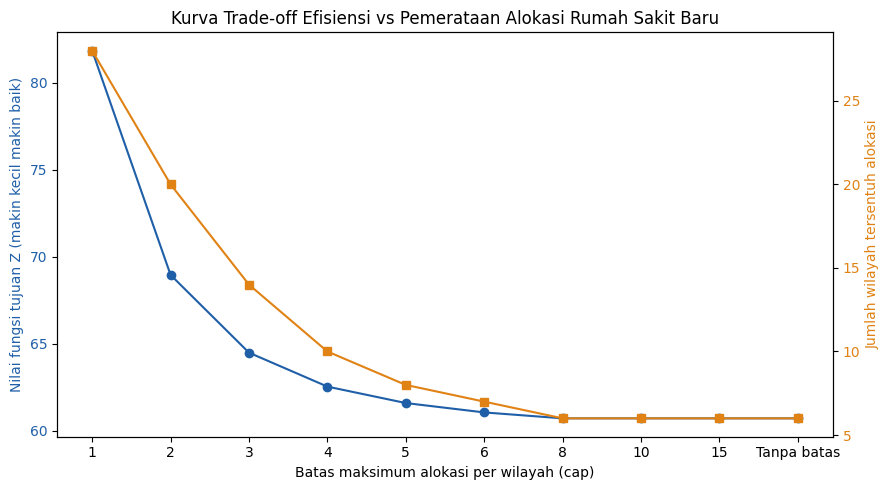

In [ ]:
caps_to_try = [1, 2, 3, 4, 5, 6, 8, 10, 15, 9999]
labels = [str(c) for c in caps_to_try[:-1]] + ["Tanpa batas"]
pareto_rows = []

for cap in caps_to_try:
    prob_c = pulp.LpProblem(f"Alokasi_cap_{cap}", pulp.LpMinimize)
    xc = {
        w: pulp.LpVariable(f"x_{i}_{cap}", lowBound=0, upBound=min(defisit[w], cap), cat="Integer")
        for i, w in enumerate(wilayah_list)
    }
    prob_c += pulp.lpSum([(defisit[w] - xc[w]) * risiko[w] for w in wilayah_list])
    prob_c += pulp.lpSum([xc[w] for w in wilayah_list]) <= BUDGET_UNIT
    prob_c.solve(pulp.PULP_CBC_CMD(msg=0))

    obj_val = pulp.value(prob_c.objective)
    n_regions = sum(1 for w in wilayah_list if xc[w].value() and xc[w].value() > 0)
    pareto_rows.append({"cap_per_wilayah": cap, "nilai_objektif": obj_val, "jumlah_wilayah_tersentuh": n_regions})

pareto_df = pd.DataFrame(pareto_rows)
print(pareto_df.to_string(index=False))

x_pos = list(range(len(caps_to_try)))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(x_pos, pareto_df["nilai_objektif"], marker="o", color="#1f5fa8", label="Nilai fungsi tujuan Z")
ax1.set_xlabel("Batas maksimum alokasi per wilayah (cap)")
ax1.set_ylabel("Nilai fungsi tujuan Z (makin kecil makin baik)", color="#1f5fa8")
ax1.tick_params(axis="y", labelcolor="#1f5fa8")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)

ax2 = ax1.twinx()
ax2.plot(x_pos, pareto_df["jumlah_wilayah_tersentuh"], marker="s", color="#e08214", label="Jumlah wilayah tersentuh")
ax2.set_ylabel("Jumlah wilayah tersentuh alokasi", color="#e08214")
ax2.tick_params(axis="y", labelcolor="#e08214")

plt.title("Kurva Trade-off Efisiensi vs Pemerataan Alokasi Rumah Sakit Baru")
fig.tight_layout()
plt.savefig("pareto_frontier.png", dpi=200, bbox_inches="tight")
plt.show()

## Cell 15
## Analisis Sensitivitas Anggaran

### Tujuan
Skenario B pada Cell 12 mengasumsikan anggaran sebesar `BUDGET_UNIT = 40` unit, yang bersifat ilustratif. Cell ini menguji **apakah rekomendasi kebijakan tetap masuk akal jika angka anggaran riil berbeda**, dengan memvariasikan anggaran sambil mempertahankan `CAP_PER_WILAYAH = 4` (setting Skenario B).

### Metode
Untuk setiap nilai anggaran dalam `[20, 40, 60, 80]` unit, model diselesaikan ulang, lalu dicatat jumlah wilayah tersentuh dan **persentase total defisit yang berhasil terpenuhi** (`rs_terbangun / total_defisit × 100`, dengan total defisit se-Jatim = 143 unit dari Cell 10).

### Hasil & Interpretasi
| Anggaran | % Defisit Terpenuhi | Wilayah Tersentuh |
|---|---|---|
| 20 unit | 14% | 5 |
| 40 unit | 28% | 10 |
| 60 unit | 42% | 16 |
| 80 unit | 55,9% | 21 |

Kenaikan cakupan defisit terpenuhi **hampir linear** terhadap anggaran, tanpa titik jenuh tajam pada rentang yang diuji. Ini menunjukkan rekomendasi kebijakan (pendekatan Skenario B) bersifat **robust** tetap relevan diterapkan pada berbagai skenario anggaran riil, tidak hanya pada asumsi 40 unit yang dipakai sebagai ilustrasi utama.

Total defisit RS se-Jatim: 143 unit

 anggaran_unit  nilai_objektif  jumlah_wilayah_tersentuh  rs_terbangun  persen_defisit_terpenuhi
            20       78.994244                         5            20                      14.0
            40       62.527979                        10            40                      28.0
            60       49.340485                        16            60                      42.0
            80       40.774635                        21            80                      55.9


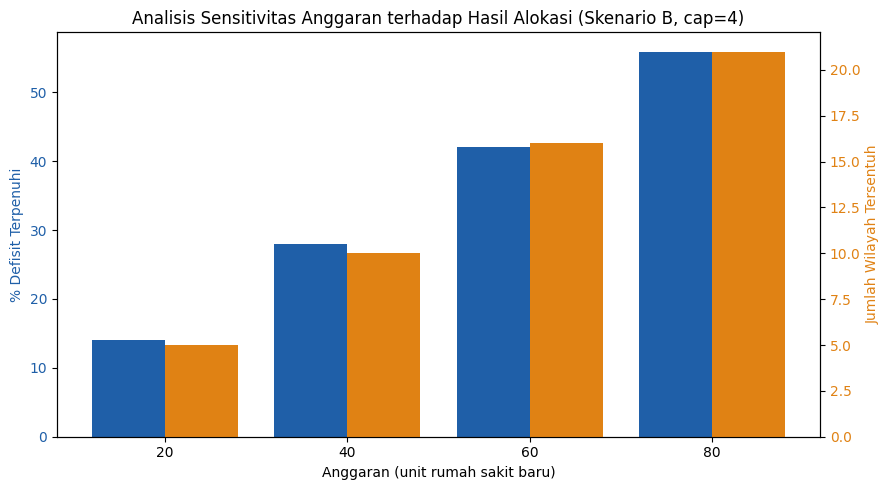

In [16]:
budget_options = [20, 40, 60, 80]
sensitivity_rows = []
total_defisit = sum(defisit.values())

for budget in budget_options:
    prob_s = pulp.LpProblem(f"Alokasi_budget_{budget}", pulp.LpMinimize)
    xs = {
        w: pulp.LpVariable(f"xs_{i}_{budget}", lowBound=0, upBound=min(defisit[w], CAP_PER_WILAYAH), cat="Integer")
        for i, w in enumerate(wilayah_list)
    }
    prob_s += pulp.lpSum([(defisit[w] - xs[w]) * risiko[w] for w in wilayah_list])
    prob_s += pulp.lpSum([xs[w] for w in wilayah_list]) <= budget
    prob_s.solve(pulp.PULP_CBC_CMD(msg=0))

    obj_val = pulp.value(prob_s.objective)
    n_regions = sum(1 for w in wilayah_list if xs[w].value() and xs[w].value() > 0)
    rs_dibangun = sum(xs[w].value() for w in wilayah_list)
    pct_defisit_terpenuhi = rs_dibangun / total_defisit * 100

    sensitivity_rows.append({
        "anggaran_unit": budget,
        "nilai_objektif": obj_val,
        "jumlah_wilayah_tersentuh": n_regions,
        "rs_terbangun": int(rs_dibangun),
        "persen_defisit_terpenuhi": round(pct_defisit_terpenuhi, 1)
    })

sens_df = pd.DataFrame(sensitivity_rows)
print(f"Total defisit RS se-Jatim: {int(total_defisit)} unit\n")
print(sens_df.to_string(index=False))

x_pos = list(range(len(budget_options)))
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar([p - 0.2 for p in x_pos], sens_df["persen_defisit_terpenuhi"], width=0.4, color="#1f5fa8", label="% Defisit Terpenuhi")
ax1.set_xticks(x_pos)
ax1.set_xticklabels([str(b) for b in budget_options])
ax1.set_xlabel("Anggaran (unit rumah sakit baru)")
ax1.set_ylabel("% Defisit Terpenuhi", color="#1f5fa8")
ax1.tick_params(axis="y", labelcolor="#1f5fa8")

ax2 = ax1.twinx()
ax2.bar([p + 0.2 for p in x_pos], sens_df["jumlah_wilayah_tersentuh"], width=0.4, color="#e08214", label="Jumlah Wilayah Tersentuh")
ax2.set_ylabel("Jumlah Wilayah Tersentuh", color="#e08214")
ax2.tick_params(axis="y", labelcolor="#e08214")

plt.title("Analisis Sensitivitas Anggaran terhadap Hasil Alokasi (Skenario B, cap=4)")
fig.tight_layout()
plt.savefig("sensitivitas_anggaran.png", dpi=200, bbox_inches="tight")
plt.show()